# 4. Cross-Model Comparison

This notebook aggregates results from all experiments (SmolVLM-256M-Instruct and Qwen3-VL-2B-Instruct, across zero-shot, one-shot, and two SFT configurations) into a single comparison table and chart. Based on the analysis, a model is selected for the Streamlit application (Task 2).

All results are loaded from Google Drive JSON files produced by `2_smolvlm.ipynb` and `3_qwen3vl_1dataset.ipynb` / `3_qwen3vl_2datasets.ipynb`.

In [5]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [6]:
import json
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
SAVE_DIR = "/content/drive/MyDrive/latex_ocr"

## 4.1. Analysis

In [3]:
rows = []

# SmolVLM
smolvlm_zs_os = os.path.join(SAVE_DIR, "smolvlm_zs_os_results.json")
if os.path.exists(smolvlm_zs_os):
    with open(smolvlm_zs_os) as f:
        data = json.load(f)
    for key, label in [("zero_shot", "SmolVLM Zero-shot"),
                       ("one_shot", "SmolVLM One-shot")]:
        r = data["results"][key]
        rows.append({"Setup": label,
                      "Exact Match": r['exact_match'],
                      "EM (norm.)": r['exact_match_normalized'],
                      "CER": r['cer'],
                      "BLEU": r['bleu'],
                      "Time (s/ex)": r['inference_time_per_example']})

for fname, label in [("smolvlm_lora_1dataset_results.json", "SmolVLM SFT (LaTeX_OCR)"),
                      ("smolvlm_lora_2datasets_results.json", "SmolVLM SFT (combined)")]:
    path = os.path.join(SAVE_DIR, fname)
    if os.path.exists(path):
        with open(path) as f:
            data = json.load(f)
        r = data["results"]
        rows.append({"Setup": label,
                      "Exact Match": r['exact_match'],
                      "EM (norm.)": r['exact_match_normalized'],
                      "CER": r['cer'],
                      "BLEU": r['bleu'],
                      "Time (s/ex)": r.get('inference_time_per_example')})

# Qwen3-VL
qwen_zs_os = os.path.join(SAVE_DIR, "qwen3vl_zs_os_results.json")
if os.path.exists(qwen_zs_os):
    with open(qwen_zs_os) as f:
        data = json.load(f)
    for key, label in [("zero_shot", "Qwen3-VL Zero-shot"),
                       ("one_shot", "Qwen3-VL One-shot")]:
        r = data["results"][key]
        rows.append({"Setup": label,
                      "Exact Match": r['exact_match'],
                      "EM (norm.)": r['exact_match_normalized'],
                      "CER": r['cer'],
                      "BLEU": r['bleu'],
                      "Time (s/ex)": r['inference_time_per_example']})

for fname, label in [("qwen3vl_lora_1dataset_results.json", "Qwen3-VL SFT (LaTeX_OCR)"),
                      ("qwen3vl_lora_2datasets_results.json", "Qwen3-VL SFT (combined)")]:
    path = os.path.join(SAVE_DIR, fname)
    if os.path.exists(path):
        with open(path) as f:
            data = json.load(f)
        r = data["results"]
        rows.append({"Setup": label,
                      "Exact Match": r['exact_match'],
                      "EM (norm.)": r['exact_match_normalized'],
                      "CER": r['cer'],
                      "BLEU": r['bleu'],
                      "Time (s/ex)": r.get('inference_time_per_example')})

df = pd.DataFrame(rows)

metric_cols = ["Exact Match", "EM (norm.)", "CER", "BLEU", "Time (s/ex)"]

(df.style
    .background_gradient(subset=metric_cols, cmap="coolwarm", axis=0)
    .format({"Exact Match": "{:.1%}", "EM (norm.)": "{:.1%}", "CER": "{:.1%}",
             "BLEU": "{:.1f}", "Time (s/ex)": "{:.1f}"})
    .hide(axis="index"))


Setup,Exact Match,EM (norm.),CER,BLEU,Time (s/ex)
SmolVLM Zero-shot,0.0%,20.0%,60.5%,49.7,1.1
SmolVLM One-shot,0.0%,15.7%,45.6%,42.4,1.1
SmolVLM SFT (LaTeX_OCR),70.0%,70.0%,8.1%,91.4,2.6
SmolVLM SFT (combined),80.0%,80.0%,4.1%,95.0,2.4
Qwen3-VL Zero-shot,0.0%,0.0%,24.1%,73.6,4.9
Qwen3-VL One-shot,4.3%,10.0%,21.0%,81.3,7.3
Qwen3-VL SFT (LaTeX_OCR),94.3%,94.3%,0.4%,98.9,5.7
Qwen3-VL SFT (combined),85.7%,85.7%,3.3%,95.1,5.8



The comparison table reveals several patterns across the two model families.

**Pre-trained capability.** Qwen3-VL-2B has substantially stronger baselines than SmolVLM-256M: zero-shot CER of 24.1% vs. 60.5%, and BLEU of 73.6 vs. 49.7. This reflects the 8x larger parameter count and more capable pre-training. One-shot inference also behaves differently: Qwen3-VL consistently improves over zero-shot on all metrics (the 2B model can leverage the demonstration), while SmolVLM shows a mixed pattern (one-shot reduces CER but hurts EM and BLEU, likely because the additional image confuses the 256M model's limited attention).

**SFT improvement.** Fine-tuning transforms both models. SmolVLM goes from 0% EM to 70-80%, and Qwen3-VL from 0-4.3% to 85.7-94.3%. EM and EM (norm.) are identical for all SFT rows, meaning every correct prediction is character-perfect.

**Combined-dataset effect.** The impact of adding MathWriting examples is opposite for the two models. SmolVLM improves by 10 pp EM (70% to 80%) and 4.0 pp CER (8.1% to 4.1%), while Qwen3-VL degrades by 8.6 pp EM (94.3% to 85.7%). As discussed in Section 4.1 of `3_qwen3vl_1dataset.ipynb`, Qwen3-VL's 94.3% on a single dataset may partly reflect same-distribution specialisation — both its train and test splits come from the same LaTeX_OCR source and share its background style and notation conventions, which the model can exploit during fine-tuning. The combined-dataset model trades some of this same-distribution accuracy for broader generalisation. SmolVLM, with its smaller capacity, benefits from the additional training signal.

**Inference speed.** SmolVLM is 2-3x faster across all setups: 1.1-2.6 s/example vs. 4.9-7.3 s/example for Qwen3-VL. This reflects the 8x difference in parameter count and is relevant for interactive applications where the user waits for each prediction.

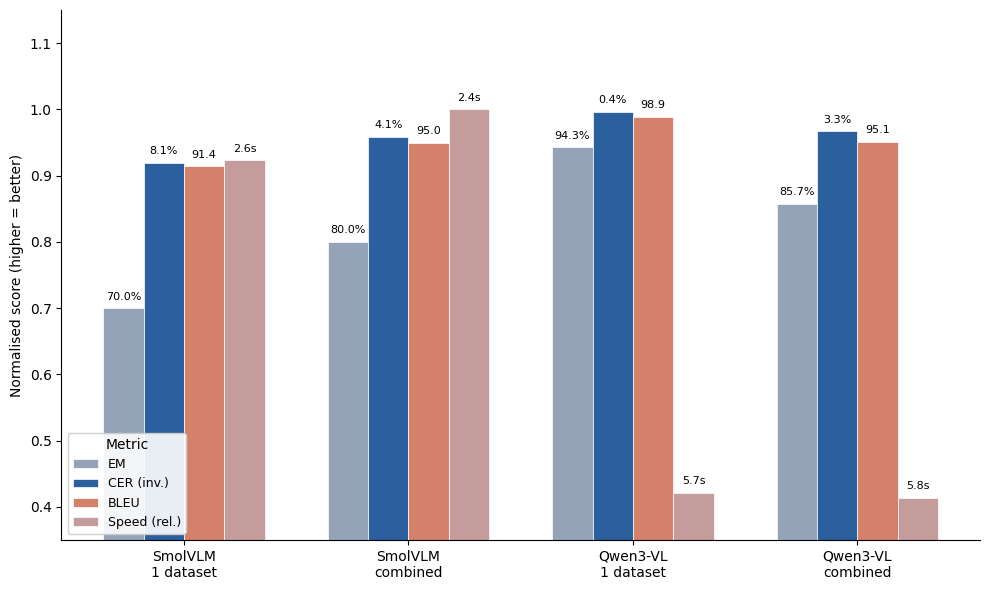

In [9]:
# SFT-only comparison (4 models x 4 metrics)

sft_rows = df[df["Setup"].str.contains("SFT")].copy()

labels_short = ["SmolVLM\n1 dataset", "SmolVLM\ncombined",
               "Qwen3-VL\n1 dataset", "Qwen3-VL\ncombined"]

# Raw values
em_vals   = sft_rows["Exact Match"].values * 100
cer_vals  = sft_rows["CER"].values * 100
bleu_vals = sft_rows["BLEU"].values
time_vals = sft_rows["Time (s/ex)"].values

# Normalize to 0-1 (higher = better)
em_n   = em_vals / 100
cer_n  = 1 - cer_vals / 100
bleu_n = bleu_vals / 100
t_min  = time_vals.min()
time_n = t_min / time_vals  # relative speed (fastest = 1.0)

# Now: 4 model groups, each with 4 metric bars
metric_names = ["EM", "CER (inv.)", "BLEU", "Speed (rel.)"]
metric_colors = ["#94A3B8", "#2B5F9E", "#D4816B", "#C49C9C"]

x = np.arange(len(labels_short))        # 4 model groups
width = 0.18
offsets = np.array([-1.5, -0.5, 0.5, 1.5])

norm_vals   = [em_n, cer_n, bleu_n, time_n]
actual_vals = [em_vals, cer_vals, bleu_vals, time_vals]
actual_fmts = ["{:.1f}%", "{:.1f}%", "{:.1f}", "{:.1f}s"]

fig, ax = plt.subplots(figsize=(10, 6))
fig.patch.set_facecolor('white')
ax.set_facecolor('white')

for i in range(4):  # 4 metrics
    bars = ax.bar(x + offsets[i] * width, norm_vals[i], width,
                  label=metric_names[i], color=metric_colors[i],
                  edgecolor='white', linewidth=0.5)
    for bar, val in zip(bars, actual_vals[i]):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01,
                actual_fmts[i].format(val), ha='center', va='bottom', fontsize=8)

ax.set_xticks(x)
ax.set_xticklabels(labels_short, fontsize=10)
ax.set_ylabel("Normalised score (higher = better)", fontsize=10)
ax.set_ylim(0.35, 1.15)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.legend(loc='lower left', fontsize=9, framealpha=0.9, title="Metric")

plt.tight_layout()
plt.show()

## 4.2. Model Selection for the Application

For the Streamlit application, we select **SmolVLM-256M-Instruct fine-tuned on the combined dataset** (LaTeX_OCR + MathWriting). The reasoning follows.

**Accuracy and generalisation.** SmolVLM on the combined dataset achieves 80% EM and 4.1% CER, meaning 56 out of 70 test formulas are reproduced character-perfectly, and the average error is roughly one character per formula. While Qwen3-VL-1ds achieves a higher 94.3% EM, this figure should be interpreted as an upper bound on same-distribution performance: both its train and test splits come from the same LaTeX_OCR source and share its background style and notation conventions, which the model can exploit during fine-tuning. The SmolVLM combined model, having been exposed to MathWriting's diverse light backgrounds, is likely more robust to real-world input variation — a critical advantage for an application that processes user-uploaded photos rather than curated dataset images.

**Speed.** At 2.4 s/example, SmolVLM is 2.4x faster than Qwen3-VL (5.7-5.8 s/ex). For an interactive Streamlit application where the user uploads an image and waits for the result, this difference directly affects user experience: approximately 3 seconds of processing time vs. nearly 6 seconds per formula.

**Combined-dataset benefit.** Unlike Qwen3-VL, SmolVLM benefits from the additional data: +10 pp EM, -4.0 pp CER, +3.6 BLEU. The combined model is strictly better than the single-dataset model on every metric, confirming that the broader training distribution improves rather than degrades performance for this model size.

**Deployment efficiency.** The 256M-parameter model requires substantially less memory than the 2B model, making it easier to deploy on resource-constrained servers and potentially feasible to run locally without a GPU.

In summary, SmolVLM-256M on the combined dataset offers the best balance of accuracy, generalisation, speed, and deployment efficiency for a practical LaTeX OCR application.